# Validación estadística

Sección separada de la herramienta operativa del pipeline (Snakemake + interfaz web). Analiza, con muestras reales aportadas para este fin, qué tan bien concuerdan las predicciones genotípicas del pipeline con los fenotipos de referencia documentados para cada una.

Estructura de este notebook:

1. [Muestras reales](#Muestras-reales)
2. [Resultados por muestra](#Resultados-por-muestra)
3. [Discusión](#Discusión)

El pipeline ya corrió (en modo solo-ensamblaje, ver `validacion_estadistica/run_validation_batch.py`) sobre las 92 muestras. `prepare_statistics_input.py` junta la comparación contra el estándar de referencia de cada muestra (`resultados/tables/reference_comparison/`) con CheckM, QUAST, MLST y la categoría de control, en `resultados/tables/validation_summary.tsv`. Este notebook parte de esa tabla ya agregada; ningún cálculo estadístico se hace en Python, solo aquí en R.

In [1]:
suppressPackageStartupMessages({
  library(readr)
  library(caret)
  library(irr)
  library(ggplot2)
})

base_dir <- ".."
stats_dir <- file.path(base_dir, "resultados/estadisticas")
plots_dir <- file.path(stats_dir, "plots")
dir.create(plots_dir, recursive = TRUE, showWarnings = FALSE)

## Muestras reales

Listado y metadatos de las muestras usadas para la validación estadística (`validacion_estadistica/muestras/`): identificador, accesión, fenotipo de referencia documentado, procedencia.

Conjunto de 92 genomas reales de *E. coli*, ya ensamblados, descargados de NCBI. Composición por categoría de control y tipo (positivo/negativo/especial) — ver `validacion_estadistica/README.md` para el detalle de cómo se armó este conjunto y las brechas frente al criterio original de 100 genomas.

In [2]:
samples_metadata <- read_csv(file.path(base_dir, "muestras/muestras_validacion_completo.csv"), show_col_types = FALSE)

cat("Total de muestras:", nrow(samples_metadata), "\n\n")
cat("Categoría x tipo de control:\n")
table(samples_metadata$`Clasificación`, samples_metadata$`Tipo de control`)

Total de muestras: 92 



Categoría x tipo de control:


                
                 Especial Negativo Positivo
  AmpC                  0        0       10
  CONTROL LIMITE        5        0        0
  ESBL                  0        0       47
  NEGATIVO              0       30        0

## Resultados por muestra

Resultados del pipeline para cada muestra de esta sección (`validacion_estadistica/resultados/`): genes detectados, clasificación genotípica, y su comparación contra el fenotipo de referencia.

`confusion_category` es TP/TN/FP/FN cuando la muestra tiene un estándar de referencia evaluable, o "Indeterminado" cuando no lo tiene (los 5 controles límite: su propósito es evaluar robustez del pipeline ante calidad subóptima de ensamblaje, no comparar genotipo). Primero se muestran los 17 casos discordantes (FN/FP) uno por uno — son el resultado más informativo de esta validación — y luego los 5 casos indeterminados.

In [3]:
validation_summary <- read_tsv(file.path(base_dir, "resultados/tables/validation_summary.tsv"), show_col_types = FALSE)

cat("Distribución completa (92 muestras):\n")
table(validation_summary$confusion_category)

Distribución completa (92 muestras):



           FN            FP Indeterminado            TN            TP 
           13             4             5            26            44 

In [4]:
discordant_cases <- subset(
  validation_summary,
  confusion_category %in% c("FN", "FP"),
  select = c(sample_id, category, expected_gene, detected_gene, match_type, confusion_category, completeness_status, assembly_status)
)
discordant_cases

sample_id,category,expected_gene,detected_gene,match_type,confusion_category,completeness_status,assembly_status
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GCA_018185615_1,ESBL,blaCTX-M-15,none,none,FN,PASS,FAIL
GCA_019047325_1,ESBL,blaCTX-M-3,none,none,FN,PASS,PASS
GCA_036492125_1,ESBL,blaCTX-M-2,none,none,FN,PASS,FAIL
GCA_028391205_1,ESBL,blaCTX-M-14b,none,none,FN,PASS,FAIL
GCA_017392015_1,ESBL,blaCTX-M-8,none,none,FN,FAIL,FAIL
GCA_023195715_1,ESBL,blaSHV-12,none,none,FN,PASS,PASS
GCA_024368115_1,ESBL,blaTEM-10,none,none,FN,PASS,PASS
GCA_021431105_1,ESBL,blaSHV-2,none,none,FN,PASS,PASS
GCA_022819305_1,ESBL,blaSHV-18,none,none,FN,PASS,PASS


In [5]:
indeterminate_cases <- subset(
  validation_summary,
  confusion_category == "Indeterminado",
  select = c(sample_id, category, known_result, detected_gene, completeness_status, assembly_status)
)
indeterminate_cases

sample_id,category,known_result,detected_gene,completeness_status,assembly_status
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GCA_000221905_2,CONTROL LIMITE,"No aplica (control límite por calidad de ensamblaje, no por genotipo)","blaCTX-M, blaTEM-1, cirA_I160SfsTer34, ompF_Q88PfsTer2",FAIL,FAIL
GCF_000263895_1,CONTROL LIMITE,"No aplica (control límite por calidad de ensamblaje, no por genotipo)",none,PASS,PASS
GCF_000734955_1,CONTROL LIMITE,"No aplica (control límite por calidad de ensamblaje, no por genotipo)",none,PASS,PASS
GCF_000285655_3,CONTROL LIMITE,"No aplica (control límite por calidad de ensamblaje, no por genotipo)","blaCMY-23, blaCTX-M-15, blaOXA-1, blaTEM-1",PASS,PASS
GCF_000234295_1,CONTROL LIMITE,"No aplica (control límite por calidad de ensamblaje, no por genotipo)",none,PASS,PASS


## Discusión

Interpretación conjunta de los resultados de todas las muestras de esta sección: métricas de concordancia, casos discordantes y su posible explicación, limitaciones observadas.

Las 5 muestras "Indeterminado" (controles límite, sin estándar de referencia evaluable por genotipo) se excluyen del cálculo de sensibilidad/especificidad/kappa; las 87 restantes sí tienen referencia evaluable.

In [6]:
evaluable_samples <- subset(validation_summary, confusion_category != "Indeterminado")
evaluable_samples$reference_status <- factor(evaluable_samples$reference_status, levels = c("negative", "positive"))
evaluable_samples$pipeline_status <- factor(evaluable_samples$pipeline_status, levels = c("negative", "positive"))

confusion_result <- confusionMatrix(evaluable_samples$pipeline_status, evaluable_samples$reference_status, positive = "positive")
capture.output(confusion_result, file = file.path(stats_dir, "confusion_matrix.txt"))
confusion_result

Confusion Matrix and Statistics

          Reference
Prediction negative positive
  negative       26       13
  positive        4       44
                                          
               Accuracy : 0.8046          
                 95% CI : (0.7057, 0.8819)
    No Information Rate : 0.6552          
    P-Value [Acc > NIR] : 0.001676        
                                          
                  Kappa : 0.5962          
                                          
 Mcnemar's Test P-Value : 0.052345        
                                          
            Sensitivity : 0.7719          
            Specificity : 0.8667          
         Pos Pred Value : 0.9167          
         Neg Pred Value : 0.6667          
             Prevalence : 0.6552          
         Detection Rate : 0.5057          
   Detection Prevalence : 0.5517          
      Balanced Accuracy : 0.8193          
                                          
       'Positive' Class : positive        


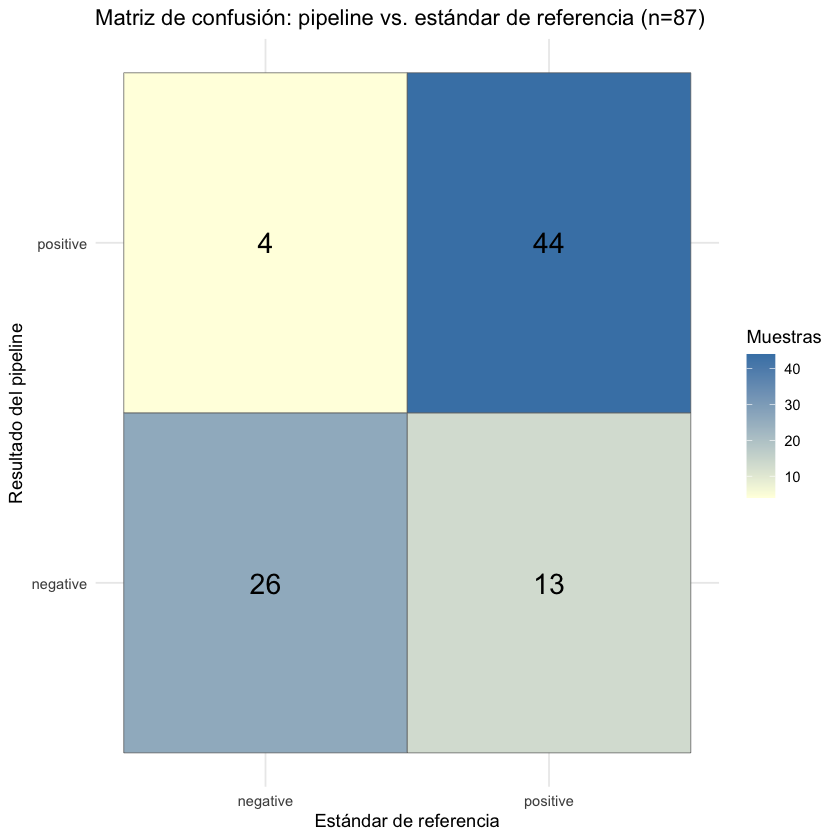

In [7]:
contingency_table <- as.data.frame(confusion_result$table)
colnames(contingency_table) <- c("pipeline_status", "reference_status", "count")
write_csv(contingency_table, file.path(stats_dir, "contingency_table.csv"))

confusion_matrix_plot <- ggplot(contingency_table, aes(x = reference_status, y = pipeline_status, fill = count)) +
  geom_tile(color = "grey40") +
  geom_text(aes(label = count), color = "black", size = 6) +
  scale_fill_gradient(low = "lightyellow", high = "steelblue") +
  labs(title = "Matriz de confusión: pipeline vs. estándar de referencia (n=87)", x = "Estándar de referencia", y = "Resultado del pipeline", fill = "Muestras") +
  theme_minimal()
ggsave(file.path(plots_dir, "confusion_matrix_heatmap.png"), confusion_matrix_plot, width = 6, height = 5)
confusion_matrix_plot

Sensibilidad y especificidad con su intervalo de confianza del 95% (Clopper-Pearson vía `binom.test`), igual criterio que `workflow/scripts/run_statistics.R` en la sección operativa del pipeline: `confusionMatrix` de `caret` ya calcula un IC del 95% para la exactitud global, pero no por separado para sensibilidad y especificidad.

In [8]:
compute_rate_with_ci <- function(successes, total) {
  if (total == 0) return(list(estimate = NA_real_, ci_lower = NA_real_, ci_upper = NA_real_))
  test_result <- binom.test(successes, total)
  list(estimate = unname(test_result$estimate), ci_lower = test_result$conf.int[1], ci_upper = test_result$conf.int[2])
}

confusion_counts <- confusion_result$table
true_positive_count <- confusion_counts["positive", "positive"]
false_negative_count <- confusion_counts["negative", "positive"]
true_negative_count <- confusion_counts["negative", "negative"]
false_positive_count <- confusion_counts["positive", "negative"]

sensitivity_stats <- compute_rate_with_ci(true_positive_count, true_positive_count + false_negative_count)
specificity_stats <- compute_rate_with_ci(true_negative_count, true_negative_count + false_positive_count)
accuracy_overall <- confusion_result$overall

classification_metrics <- data.frame(
  metric = c("Sensitivity", "Specificity", "Accuracy"),
  estimate = c(sensitivity_stats$estimate, specificity_stats$estimate, unname(accuracy_overall["Accuracy"])),
  ci_lower = c(sensitivity_stats$ci_lower, specificity_stats$ci_lower, unname(accuracy_overall["AccuracyLower"])),
  ci_upper = c(sensitivity_stats$ci_upper, specificity_stats$ci_upper, unname(accuracy_overall["AccuracyUpper"])),
  n = c(true_positive_count + false_negative_count, true_negative_count + false_positive_count, nrow(evaluable_samples))
)
write_csv(classification_metrics, file.path(stats_dir, "classification_metrics.csv"))
classification_metrics

metric,estimate,ci_lower,ci_upper,n
<chr>,<dbl>,<dbl>,<dbl>,<int>
Sensitivity,0.7719298,0.6416366,0.8726029,57
Specificity,0.8666667,0.6927816,0.9624465,30
Accuracy,0.8045977,0.7056802,0.8818513,87


Índice kappa de Cohen: concordancia entre el estándar de referencia y el resultado del pipeline, corrigiendo por el acuerdo esperado al azar.

In [9]:
kappa_result <- kappa2(data.frame(evaluable_samples$reference_status, evaluable_samples$pipeline_status))
kappa_summary <- data.frame(
  kappa_value = kappa_result$value,
  z_statistic = kappa_result$statistic,
  p_value = kappa_result$p.value,
  n_samples = kappa_result$subjects
)
write_csv(kappa_summary, file.path(stats_dir, "kappa.csv"))
kappa_summary

kappa_value,z_statistic,p_value,n_samples
<dbl>,<dbl>,<dbl>,<int>
0.5962326,5.69287,1.249213e-08,87


In [10]:
category_breakdown <- as.data.frame.matrix(table(validation_summary$category, validation_summary$confusion_category))
write_csv(cbind(category = rownames(category_breakdown), category_breakdown), file.path(stats_dir, "category_breakdown.csv"))
category_breakdown

,FN,FP,Indeterminado,TN,TP
,<int>,<int>,<int>,<int>,<int>
AmpC,2,0,0,0,8
CONTROL LIMITE,0,0,5,0,0
ESBL,11,0,0,0,36
NEGATIVO,0,4,0,26,0


### Interpretación

Sobre las 87 muestras con estándar de referencia evaluable: **sensibilidad 77.2%** (IC 95%: 64.2%–87.3%, n=57 positivos), **especificidad 86.7%** (IC 95%: 69.3%–96.2%, n=30 negativos), **exactitud 80.5%** (IC 95%: 70.6%–88.2%). **Kappa = 0.596** (p = 1.2×10⁻⁸): concordancia moderada-sustancial y estadísticamente muy por encima del azar, pero claramente por debajo de la concordancia casi perfecta que buscaría una herramienta lista para uso clínico — consistente con el alcance de este proyecto (demostrar factibilidad técnica, no validar para uso diagnóstico).

**13 falsos negativos** (11 ESBL, 2 AmpC): en los revisados, AMRFinderPlus no encontró ningún hit para el gen esperado ni siquiera antes de aplicar el umbral de identidad/cobertura — es decir, no es un problema del umbral de esta ejecución, la base de datos no encontró el gen en el ensamblaje. 6 de las 13 coinciden con un ensamblaje que también falló QUAST (`assembly_status = FAIL`, posible fragmentación del gen entre contigs), pero las otras 7 tienen ensamblaje y completitud normales, sin explicación técnica evidente desde estas métricas. La causa más probable, documentada ya en `validacion_estadistica/muestras/README.md`, es la escasez del pool de genomas de *E. coli* con blaSHV/blaTEM/AmpC plasmídica ya ensamblados en NCBI: varias posiciones del conjunto original tuvieron que sustituirse por accesiones cuyo fenotipo de referencia (columna `Resultado conocido`, tomada del Excel de origen) no siempre pudo verificarse de forma independiente gen por gen, a diferencia de los negativos (verificados por identidad de cepa). Esto es una limitación del **estándar de referencia**, no necesariamente del pipeline.

**4 falsos positivos**, todos en la categoría NEGATIVO: 2 son `blaTEM-1` (beta-lactamasa de espectro estrecho, no ESBL ni AmpC) y 2 son mutaciones puntuales en `cirA` (gen de receptor de membrana, catalogado por AMRFinderPlus como BETA-LACTAM pero no como un gen de resistencia adquirida a cefalosporinas de tercera generación). El estándar de referencia de estas muestras ("ausencia de ESBL adquirida y AmpC plasmídica") es más estrecho que la regla de comparación genotípica de este pipeline (`compare_to_reference.py`), que marca como inesperada *cualquier* beta-lactamasa de la clase BETA-LACTAM detectada en una muestra negativa. `blaTEM-1` en particular es común de forma incidental en *E. coli* y no confiere por sí solo resistencia a cefalosporinas de tercera generación. Es un desajuste de alcance entre la definición del control negativo y la regla de comparación, no una falla de detección del pipeline.

**Limitación no resuelta — coeficiente de variación (reproducibilidad):** `muestras_validacion_completo.csv` marca 5 muestras como "control de reproducibilidad: correr en 3 corridas independientes", pero `run_validation_batch.py` (a diferencia del pipeline operativo) corre cada muestra una sola vez y no captura tiempo/RAM por corrida. El CV de tiempo de ejecución y RAM (ver `workflow/scripts/run_statistics.R` para el criterio ya usado en la sección operativa) queda **pendiente** para esta sección: requeriría extender `run_validation_batch.py` para correr esas 5 muestras 3 veces cada una y registrar `elapsed_seconds`/`max_ram_gb` por corrida.